# Speed dating

In [386]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from sklearn.manifold import TSNE
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [387]:
df = pd.read_csv('./data/speeddating.csv')
df.head(3)

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,b'',1.0,b'female',21.0,27.0,6.0,b'[4-6]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'0',b'0'
1,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,5.0,b'[6-8]',b'[5-6]',1.0,b'1',b'0',b'0'
2,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',...,b'[0-3]',b'[3-5]',7.0,NaN,b'[6-8]',b'[0-4]',1.0,b'1',b'1',b'1'


In [388]:
columns_to_drop = ['has_null', 'wave', 'd_d_age', 'd_importance_same_race', 'd_importance_same_religion',
                   'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence',
                   'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests',
                   'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 
                   'd_shared_interests_o', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important',
                   'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
                   'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important',
                   'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition',
                   'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner', 
                   'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner',
                   'd_shared_interests_partner', 'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums',
                   'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv', 'd_theater', 'd_movies',
                   'd_concerts', 'd_music', 'd_shopping', 'd_yoga', 'd_interests_correlate',
                   'd_expected_happy_with_sd_people', 'd_expected_num_interested_in_me', 'd_expected_num_matches',
                   'd_like', 'd_guess_prob_liked', 'like', 'guess_prob_liked', 'decision', 'decision_o']
print(len(columns_to_drop))

df = df.drop(columns=columns_to_drop)
df.head(3)

73


,gender,age,age_o,d_age,race,race_o,samerace,importance_same_race,importance_same_religion,field,...,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,met,match
0,b'female',21.0,27.0,6.0,b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',2.0,4.0,b'Law',...,10.0,9.0,8.0,1.0,0.14,3.0,2.0,4.0,0.0,b'0'
1,b'female',21.0,22.0,1.0,b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',2.0,4.0,b'Law',...,10.0,9.0,8.0,1.0,0.54,3.0,2.0,4.0,1.0,b'0'
2,b'female',21.0,22.0,1.0,b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',2.0,4.0,b'Law',...,10.0,9.0,8.0,1.0,0.16,3.0,2.0,4.0,1.0,b'1'


In [389]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         8378 non-null   str    
 1   age                            8283 non-null   float64
 2   age_o                          8274 non-null   float64
 3   d_age                          8378 non-null   float64
 4   race                           8378 non-null   str    
 5   race_o                         8378 non-null   str    
 6   samerace                       8378 non-null   str    
 7   importance_same_race           8299 non-null   float64
 8   importance_same_religion       8299 non-null   float64
 9   field                          8378 non-null   str    
 10  pref_o_attractive              8289 non-null   float64
 11  pref_o_sincere                 8289 non-null   float64
 12  pref_o_intelligence            8289 non-null   float64
 13 

In [390]:
print("liczba duplikatów:")
print(df.duplicated().sum())
df[df.duplicated(keep=False)]

liczba duplikatów:
10


,gender,age,age_o,d_age,race,race_o,samerace,importance_same_race,importance_same_religion,field,...,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,met,match
910,b'male',29.0,NaN,29.0,b'Latino/Hispanic American',b'?',b'0',1.0,1.0,b'Business & International Affairs',...,4.0,6.0,4.0,2.0,NaN,5.0,3.0,3.0,NaN,b'0'
911,b'male',29.0,NaN,29.0,b'Latino/Hispanic American',b'?',b'0',1.0,1.0,b'Business & International Affairs',...,4.0,6.0,4.0,2.0,NaN,5.0,3.0,3.0,NaN,b'0'
920,b'male',22.0,NaN,22.0,b'Other',b'?',b'0',1.0,1.0,b'Law',...,9.0,9.0,2.0,1.0,NaN,5.0,1.0,3.0,NaN,b'0'
921,b'male',22.0,NaN,22.0,b'Other',b'?',b'0',1.0,1.0,b'Law',...,9.0,9.0,2.0,1.0,NaN,5.0,1.0,3.0,NaN,b'0'
930,b'male',27.0,NaN,27.0,b'Black/African American',b'?',b'0',1.0,1.0,b'MFA Creative Writing',...,7.0,7.0,7.0,1.0,NaN,5.0,2.0,NaN,0.0,b'0'
931,b'male',27.0,NaN,27.0,b'Black/African American',b'?',b'0',1.0,1.0,b'MFA Creative Writing',...,7.0,7.0,7.0,1.0,NaN,5.0,2.0,NaN,0.0,b'0'
940,b'male',28.0,NaN,28.0,b'European/Caucasian-American',b'?',b'0',2.0,2.0,b'MBA',...,6.0,7.0,2.0,1.0,NaN,3.0,0.0,1.0,0.0,b'0'
941,b'male',28.0,NaN,28.0,b'European/Caucasian-American',b'?',b'0',2.0,2.0,b'MBA',...,6.0,7.0,2.0,1.0,NaN,3.0,0.0,1.0,0.0,b'0'
970,b'male',22.0,NaN,22.0,b'European/Caucasian-American',b'?',b'0',8.0,1.0,b'Engineering',...,6.0,8.0,8.0,4.0,NaN,7.0,9.0,1.0,0.0,b'0'
971,b'male',22.0,NaN,22.0,b'European/Caucasian-American',b'?',b'0',8.0,1.0,b'Engineering',...,6.0,8.0,8.0,4.0,NaN,7.0,9.0,1.0,0.0,b'0'


In [391]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 8368 entries, 0 to 8377
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         8368 non-null   str    
 1   age                            8273 non-null   float64
 2   age_o                          8274 non-null   float64
 3   d_age                          8368 non-null   float64
 4   race                           8368 non-null   str    
 5   race_o                         8368 non-null   str    
 6   samerace                       8368 non-null   str    
 7   importance_same_race           8289 non-null   float64
 8   importance_same_religion       8289 non-null   float64
 9   field                          8368 non-null   str    
 10  pref_o_attractive              8289 non-null   float64
 11  pref_o_sincere                 8289 non-null   float64
 12  pref_o_intelligence            8289 non-null   float64
 13  pref

In [392]:
df = df.drop(columns=['expected_num_interested_in_me'])

In [393]:
for col in df.select_dtypes(include='str').columns:
    df[col] = df[col].str.replace("b'", "").str.replace("'", "")
df.head(3)

,gender,age,age_o,d_age,race,race_o,samerace,importance_same_race,importance_same_religion,field,...,movies,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_matches,met,match
0,female,21.0,27.0,6.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.14,3.0,4.0,0.0,0
1,female,21.0,22.0,1.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.54,3.0,4.0,1.0,0
2,female,21.0,22.0,1.0,Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.16,3.0,4.0,1.0,1



## Rozkład klasy

Text(0.5, 1.0, "Rozkład match'a")

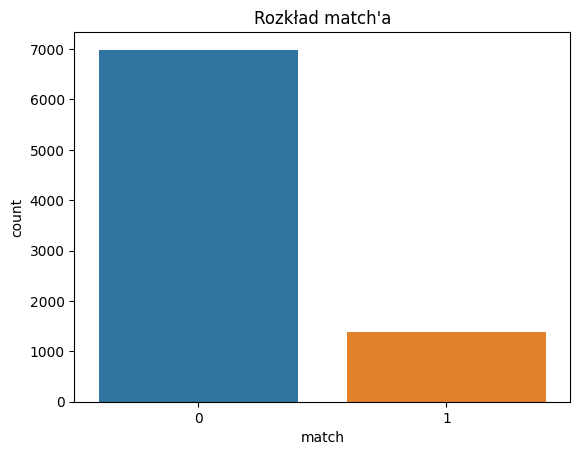

In [394]:
sns.countplot(df, x=df.match, hue='match')
plt.title('Rozkład match\'a')

### tworzenie ID

In [395]:
individual_features = ['gender', 'age', 'race', 'importance_same_race', 'importance_same_religion', 'field']

df['id'] = df.groupby(individual_features, sort=False).ngroup()

df.id

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
        ...  
8373    536.0
8374    536.0
8375    536.0
8376    536.0
8377    536.0
Name: id, Length: 8368, dtype: float64

## Rozkład cech

In [396]:
print(df.nunique().sort_values(ascending=False).to_string())

id                               537
field                            260
interests_correlate              155
pref_o_attractive                 94
attractive_important              94
pref_o_shared_interests           85
shared_interests_important        85
ambtition_important               82
pref_o_ambitious                  82
pref_o_sincere                    78
sincere_important                 78
pref_o_funny                      71
funny_important                   71
intellicence_important            65
pref_o_intelligence               65
d_age                             35
age_o                             24
age                               24
expected_num_matches              17
gaming                            12
theater                           11
reading                           11
hiking                            11
importance_same_race              11
clubbing                          11
concerts                          11
art                               11
m

In [397]:
df['field'].unique().tolist()

['Law',
 'law',
 'Economics',
 'Masters in Public Administration',
 'Masters of Social Work&Education',
 'Finance',
 'Business',
 'political science',
 'money',
 'Operations Research',
 'TC [Health Ed]',
 'Psychology',
 'social work',
 'Social Work',
 'Speech Language Pathology',
 'Speech Languahe Pathology',
 'Educational Psychology',
 'Applied Maths/Econs',
 'Mathematics',
 'Statistics',
 'Organizational Psychology',
 'Mechanical Engineering',
 'Finanace',
 'Finance&Economics',
 'Undergrad - GS',
 'Mathematical Finance',
 'Medicine',
 'MBA',
 'LAW',
 '?',
 'psychology',
 'German Literature',
 'Business & International Affairs',
 'MFA Creative Writing',
 'Engineering',
 'Electrical Engineering',
 'Classics',
 'Operations Research [SEAS]',
 'chemistry',
 'Journalism',
 'Elementary/Childhood Education [MA]',
 'microbiology',
 'Masters of Social Work',
 'Communications',
 'Marketing',
 'Chemistry',
 'International Educational Development',
 'Education Administration',
 'Business [MBA]',


In [398]:
df = df.drop(columns=['field'])

In [399]:
print(df['met'].unique().tolist())
print(df['met'].nunique())
print(df['met'].value_counts())

[0.0, 1.0, nan, 3.0, 5.0, 7.0, 8.0, 6.0]
7
met
0.0    7636
1.0     351
7.0       3
5.0       2
3.0       1
8.0       1
6.0       1
Name: count, dtype: int64


In [400]:
df['met'] = np.where(df['met'] >= 1, 1, 0)

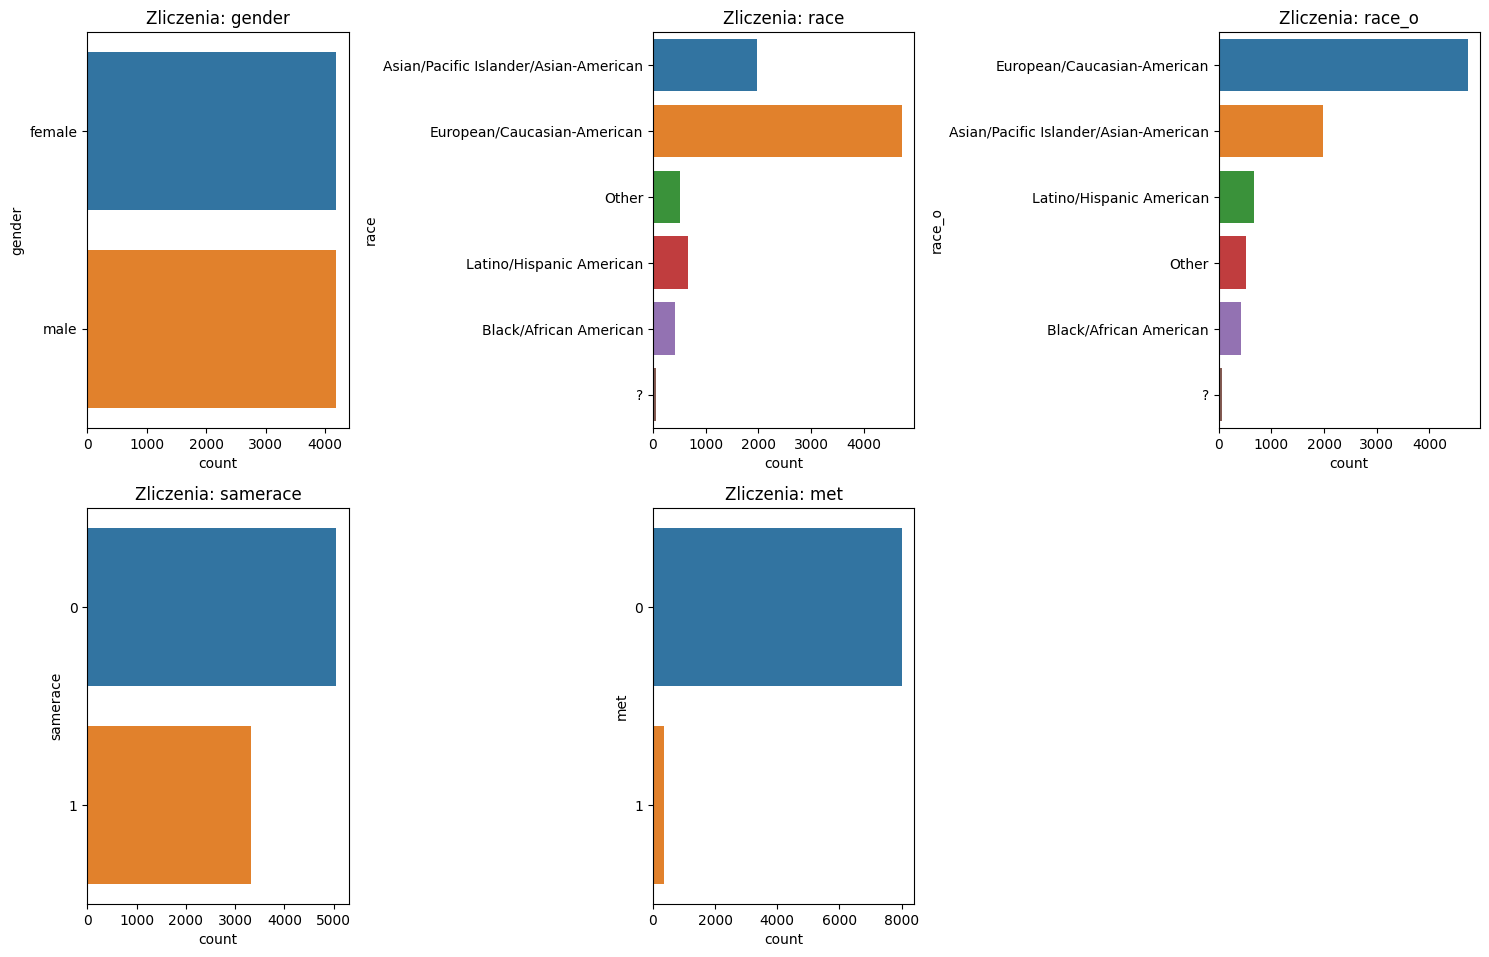

In [401]:
categorical_cols = ['gender', 'race', 'race_o', 'samerace', 'met']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, y=col, ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Zliczenia: {col}')

    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

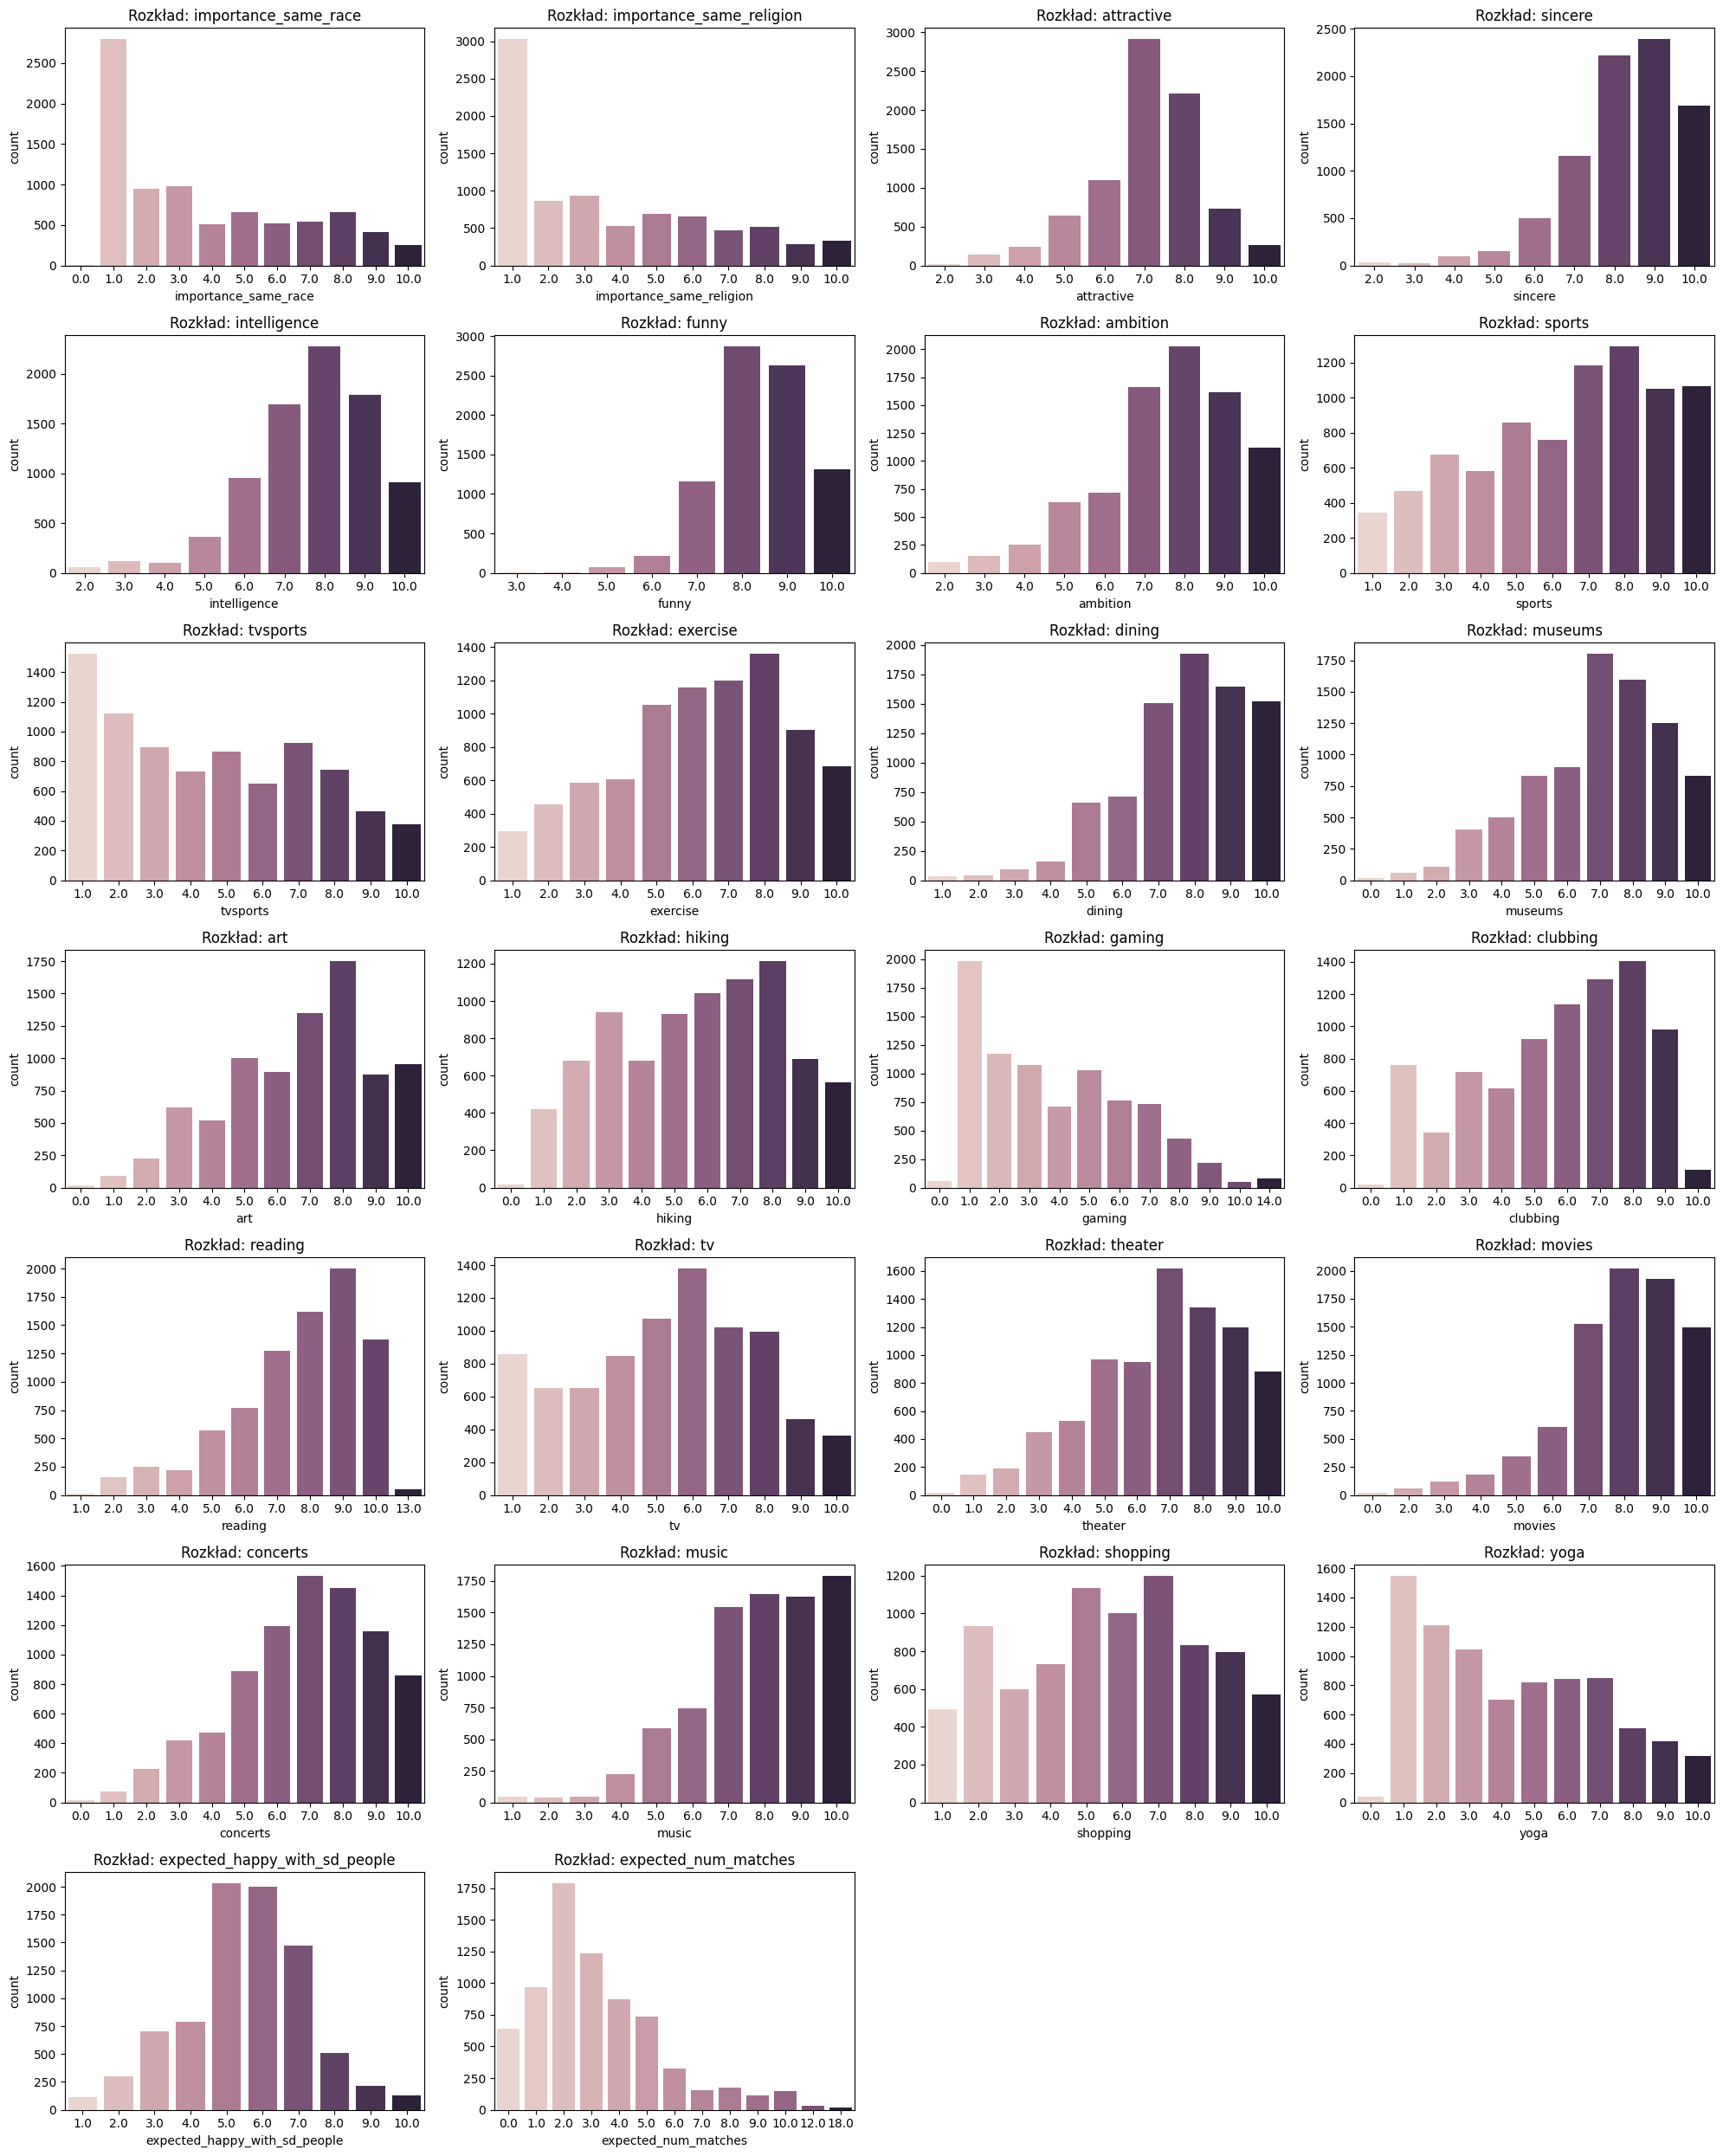

In [402]:
discrete_cols = ['importance_same_race', 'importance_same_religion', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art',  'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater',  'movies', 'concerts', 'music', 'shopping', 'yoga', 'expected_happy_with_sd_people',  'expected_num_matches']
fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    rounded_data = df[col].round()
    
    sns.countplot(x=rounded_data, ax=axes[i], hue=rounded_data, legend=False)
    axes[i].set_title(f'Rozkład: {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

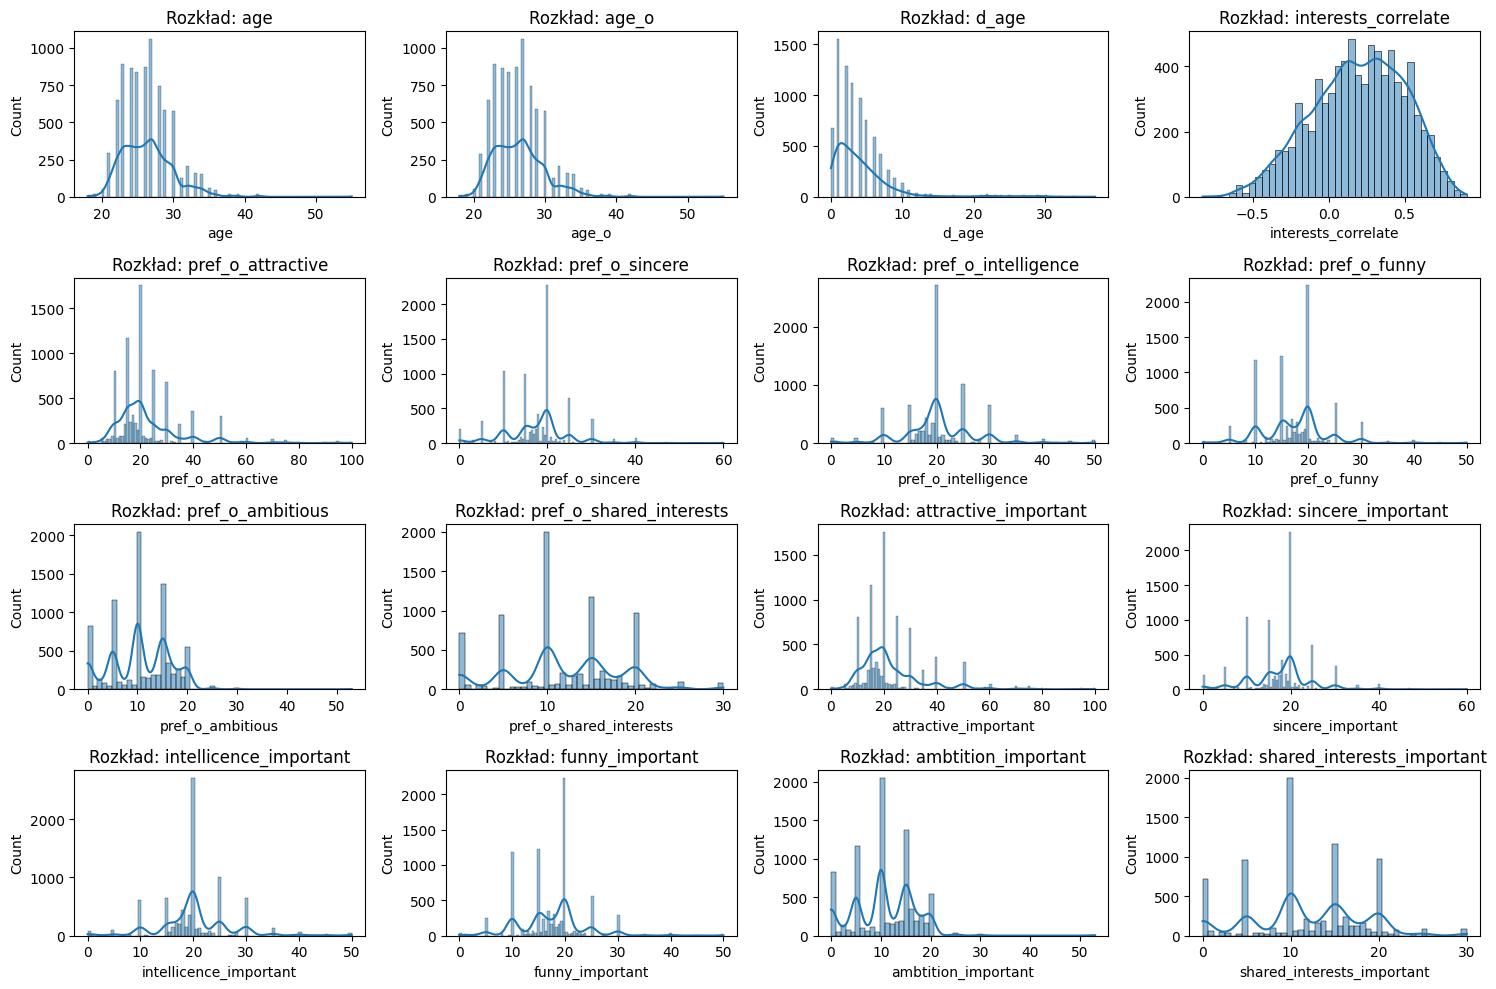

In [403]:
continuous_cols = ['age', 'age_o', 'd_age', 'interests_correlate', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Rozkład: {col}')

plt.tight_layout()
plt.show()

In [404]:
simple_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = simple_imputer.fit_transform(df[categorical_cols])

numerical_cols = continuous_cols + discrete_cols
knn_imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = knn_imputer.fit_transform(df[numerical_cols])

print("is nan number:\n", df.isna().sum())

is nan number:
 gender                             0
age                                0
age_o                              0
d_age                              0
race                               0
race_o                             0
samerace                           0
importance_same_race               0
importance_same_religion           0
pref_o_attractive                  0
pref_o_sincere                     0
pref_o_intelligence                0
pref_o_funny                       0
pref_o_ambitious                   0
pref_o_shared_interests            0
attractive_important               0
sincere_important                  0
intellicence_important             0
funny_important                    0
ambtition_important                0
shared_interests_important         0
attractive                         0
sincere                            0
intelligence                       0
funny                              0
ambition                           0
sports                

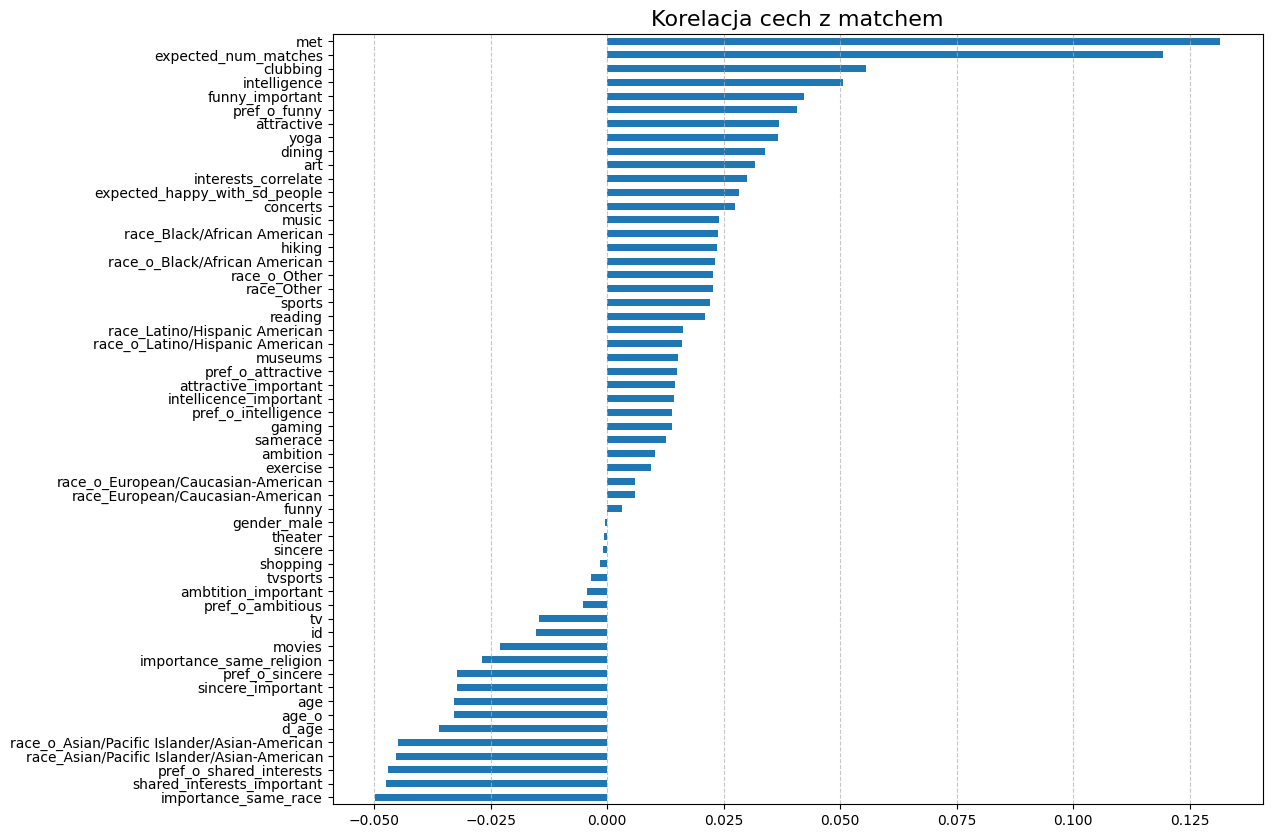

In [405]:
df['match'] = df['match'].astype('int64')
df['met'] = df['met'].astype('int64')
df['samerace'] = df['samerace'].astype('int64')

df = pd.get_dummies(df, columns=['gender', 'race', 'race_o'], drop_first=True, dtype=int)

numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

correlations = corr_matrix['match'].drop('match').sort_values()

plt.figure(figsize=(12, 10))

correlations.plot(kind='barh')

plt.title('Korelacja cech z matchem', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [406]:
df.head(7)

,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,...,race_Asian/Pacific Islander/Asian-American,race_Black/African American,race_European/Caucasian-American,race_Latino/Hispanic American,race_Other,race_o_Asian/Pacific Islander/Asian-American,race_o_Black/African American,race_o_European/Caucasian-American,race_o_Latino/Hispanic American,race_o_Other
0,21.0,27.0,6.0,0,2.0,4.0,35.0,20.0,20.0,20.0,...,1,0,0,0,0,0,0,1,0,0
1,21.0,22.0,1.0,0,2.0,4.0,60.0,0.0,0.0,40.0,...,1,0,0,0,0,0,0,1,0,0
2,21.0,22.0,1.0,1,2.0,4.0,19.0,18.0,19.0,18.0,...,1,0,0,0,0,1,0,0,0,0
3,21.0,23.0,2.0,0,2.0,4.0,30.0,5.0,15.0,40.0,...,1,0,0,0,0,0,0,1,0,0
4,21.0,24.0,3.0,0,2.0,4.0,30.0,10.0,20.0,10.0,...,1,0,0,0,0,0,0,0,1,0
5,21.0,25.0,4.0,0,2.0,4.0,50.0,0.0,30.0,10.0,...,1,0,0,0,0,0,0,1,0,0
6,21.0,30.0,9.0,0,2.0,4.0,35.0,15.0,25.0,10.0,...,1,0,0,0,0,0,0,1,0,0


### dodawanie nowych cech

In [407]:
df.columns

Index(['age', 'age_o', 'd_age', 'samerace', 'importance_same_race',
       'importance_same_religion', 'pref_o_attractive', 'pref_o_sincere',
       'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious',
       'pref_o_shared_interests', 'attractive_important', 'sincere_important',
       'intellicence_important', 'funny_important', 'ambtition_important',
       'shared_interests_important', 'attractive', 'sincere', 'intelligence',
       'funny', 'ambition', 'sports', 'tvsports', 'exercise', 'dining',
       'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv',
       'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga',
       'interests_correlate', 'expected_happy_with_sd_people',
       'expected_num_matches', 'met', 'match', 'id', 'gender_male',
       'race_Asian/Pacific Islander/Asian-American',
       'race_Black/African American', 'race_European/Caucasian-American',
       'race_Latino/Hispanic American', 'race_Other',
       'race_o_Asian/Pacific Isla

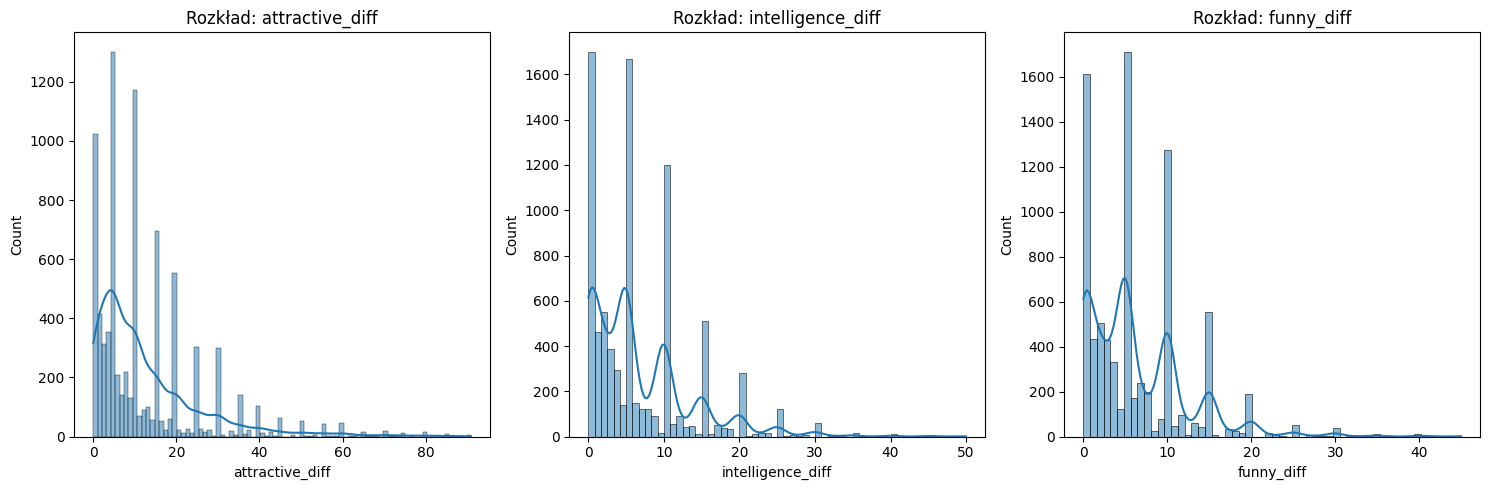

In [408]:
df['attractive_diff'] = abs(df['attractive_important'] - df['pref_o_attractive'])
df['intelligence_diff'] = abs(df['intellicence_important'] - df['pref_o_intelligence']) 
df['funny_diff'] = abs(df['funny_important'] - df['pref_o_funny'])

new_columns = ['attractive_diff', 'intelligence_diff', 'funny_diff']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(new_columns):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Rozkład: {col}')

plt.tight_layout()
plt.show()

## Podział danych na zbiór testowy i treningowy

In [409]:
X = df.drop(columns=['match', 'id']).copy()
y = df['match'].copy()
ids = df['id'].copy()

test_idx, train_idx = [], []

for sample_id, group in df.groupby('id'):
    if len(group) > 5:
        sampled = group.sample(n=5, random_state=42)
        test_idx.extend(sampled.index)
        train_idx.extend(group.drop(sampled.index).index)
    else:
        train_idx.extend(group.index)

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns, index=X_train.index)
# X_test_s = pd.DataFrame(X_test_s, columns=X_test.columns, index=X_test.index)

print(f"Rozmiar zbioru treningowego: {X_train_s.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test_s.shape[0]}")
print(X_test_s.shape[0]/(X_train_s.shape[0]+X_test_s.shape[0]))


Rozmiar zbioru treningowego: 5617
Rozmiar zbioru testowego: 2640
0.3197287150296718


In [410]:
print("Rozkład klas w zbiorze treningowym:")
print(y_train.value_counts())
print("~16%")
print("\nRozkład klas w zbiorze testowym")
print(y_test.value_counts())
print("~18%")


Rozkład klas w zbiorze treningowym:
match
0    4724
1     893
Name: count, dtype: int64
~16%

Rozkład klas w zbiorze testowym
match
0    2172
1     468
Name: count, dtype: int64
~18%


## Uczenie naiwnych klasyfikatorów

In [411]:
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(X_train_s, y_train)
y_pred_majority = dummy_majority.predict(X_test_s)

print("Naiwny klasyfikator większościowy:")
print(classification_report(y_test, y_pred_majority, zero_division=0))

dummy_random = DummyClassifier(strategy='uniform', random_state=42)
dummy_random.fit(X_train_s, y_train)
y_pred_random = dummy_random.predict(X_test_s)

print("Naiwny klasyfikator losowy:")
print(classification_report(y_test, y_pred_random))

Naiwny klasyfikator większościowy:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      2172
           1       0.00      0.00      0.00       468

    accuracy                           0.82      2640
   macro avg       0.41      0.50      0.45      2640
weighted avg       0.68      0.82      0.74      2640

Naiwny klasyfikator losowy:
              precision    recall  f1-score   support

           0       0.82      0.51      0.63      2172
           1       0.18      0.50      0.26       468

    accuracy                           0.50      2640
   macro avg       0.50      0.50      0.44      2640
weighted avg       0.71      0.50      0.56      2640



## Nauka podstawowych modeli

In [412]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)
y_pred_lr = log_reg.predict(X_test_s)

print("Wyniki regresji logistycznej:")
print(classification_report_imbalanced(y_test, y_pred_lr))

d_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
d_tree.fit(X_train_s, y_train)
y_pred_dt = d_tree.predict(X_test_s)

print("Wyniki drzewa decyzyjnego:")
print(classification_report_imbalanced(y_test, y_pred_dt))

Wyniki regresji logistycznej:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.99      0.03      0.90      0.17      0.03      2172
          1       0.48      0.03      0.99      0.06      0.17      0.03       468

avg / total       0.77      0.82      0.20      0.75      0.17      0.03      2640

Wyniki drzewa decyzyjnego:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.98      0.07      0.90      0.25      0.07      2172
          1       0.39      0.07      0.98      0.11      0.25      0.06       468

avg / total       0.75      0.82      0.23      0.76      0.25      0.07      2640



## SMOTE

In [413]:
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_s), size=1500, replace=False)

X_sample = X_train_s[sample_indices]
y_sample = y_train.iloc[sample_indices]

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

In [414]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)
print(y_train_smote.value_counts())

match
1    4724
0    4724
Name: count, dtype: int64


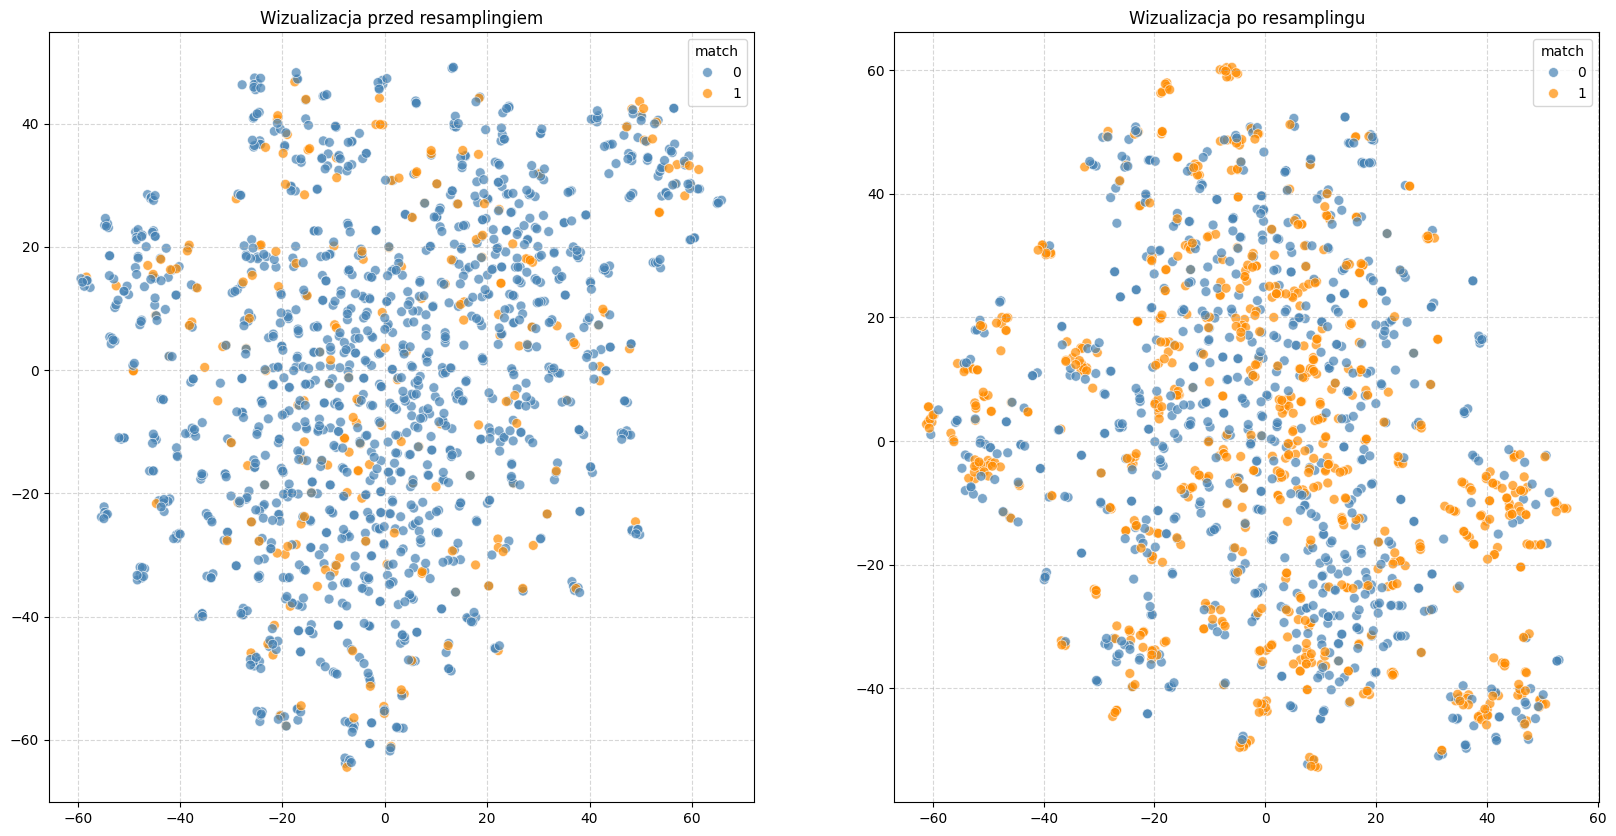

In [415]:
sample_indices_smote = np.random.choice(len(X_train_smote), size=1500, replace=False)

X_sample_smote = X_train_smote[sample_indices_smote]
y_sample_smote = y_train_smote.iloc[sample_indices_smote]

X_tsne_smote = tsne.fit_transform(X_sample_smote)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
axes = axes.flatten()

sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=y_sample, 
    palette={0: 'steelblue', 1: 'darkorange'},
    alpha=0.7,
    s=50,
    ax=axes[0]
)
axes[0].set_title('Wizualizacja przed resamplingiem')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x=X_tsne_smote[:, 0], 
    y=X_tsne_smote[:, 1], 
    hue=y_sample_smote, 
    palette={0: 'steelblue', 1: 'darkorange'},
    alpha=0.7,
    s=50,
    ax=axes[1]
)
axes[1].set_title('Wizualizacja po resamplingu')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

In [416]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)
y_pred_lr = log_reg.predict(X_test_s)

print("Wyniki regresji logistycznej:")
print(classification_report_imbalanced(y_test, y_pred_lr))

d_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
d_tree.fit(X_train_smote, y_train_smote)
y_pred_dt = d_tree.predict(X_test_s)

print("Wyniki drzewa decyzyjnego:")
print(classification_report_imbalanced(y_test, y_pred_dt))

Wyniki regresji logistycznej:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.87      0.66      0.54      0.75      0.60      0.36      2172
          1       0.26      0.54      0.66      0.35      0.60      0.35       468

avg / total       0.76      0.64      0.56      0.68      0.60      0.36      2640

Wyniki drzewa decyzyjnego:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      0.63      0.51      0.73      0.57      0.33      2172
          1       0.23      0.51      0.63      0.32      0.57      0.32       468

avg / total       0.75      0.61      0.53      0.65      0.57      0.33      2640



## Under sampling + SMOTE

In [417]:
under = RandomUnderSampler(sampling_strategy=0.45, random_state=42)
over = SMOTE(random_state=42)

pipeline = Pipeline(steps=[('u', under), ('o', over)])

X_train_under_plus_smote, y_train_under_plus_smote = pipeline.fit_resample(X_train_s, y_train)

print(y_train_under_plus_smote.value_counts())

match
0    1984
1    1984
Name: count, dtype: int64


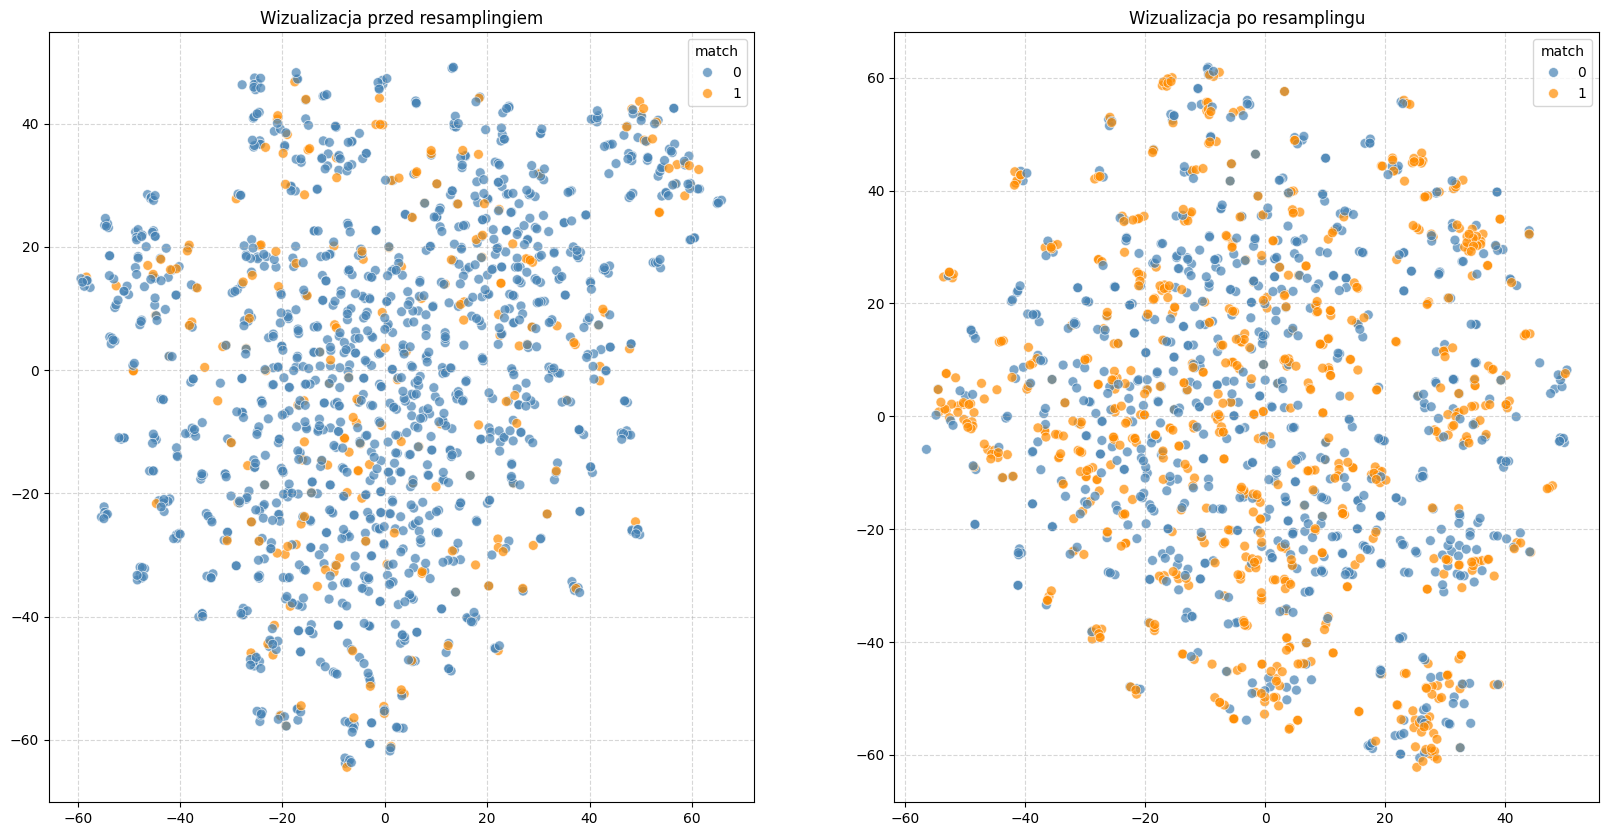

In [418]:
sample_indices_under_plus_smote = np.random.choice(len(X_train_under_plus_smote), size=1500, replace=False)

X_sample_under_plus_smote = X_train_under_plus_smote[sample_indices_under_plus_smote]
y_sample_under_plus_smote = y_train_under_plus_smote.iloc[sample_indices_under_plus_smote]

X_tsne_under_plus_smote = tsne.fit_transform(X_sample_under_plus_smote)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
axes = axes.flatten()

sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=y_sample, 
    palette={0: 'steelblue', 1: 'darkorange'},
    alpha=0.7,
    s=50,
    ax=axes[0]
)
axes[0].set_title('Wizualizacja przed resamplingiem')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x=X_tsne_under_plus_smote[:, 0], 
    y=X_tsne_under_plus_smote[:, 1], 
    hue=y_sample_under_plus_smote, 
    palette={0: 'steelblue', 1: 'darkorange'},
    alpha=0.7,
    s=50,
    ax=axes[1]
)
axes[1].set_title('Wizualizacja po resamplingu')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

In [419]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_under_plus_smote, y_train_under_plus_smote)
y_pred_lr = log_reg.predict(X_test_s)

print("Wyniki regresji logistycznej:")
print(classification_report_imbalanced(y_test, y_pred_lr))

d_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
d_tree.fit(X_train_under_plus_smote, y_train_under_plus_smote)
y_pred_dt = d_tree.predict(X_test_s)

print("Wyniki drzewa decyzyjnego:")
print(classification_report_imbalanced(y_test, y_pred_dt))

Wyniki regresji logistycznej:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.87      0.66      0.53      0.75      0.59      0.35      2172
          1       0.25      0.53      0.66      0.34      0.59      0.34       468

avg / total       0.76      0.63      0.55      0.67      0.59      0.35      2640

Wyniki drzewa decyzyjnego:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      0.72      0.44      0.78      0.56      0.32      2172
          1       0.25      0.44      0.72      0.32      0.56      0.30       468

avg / total       0.75      0.67      0.49      0.70      0.56      0.32      2640



## SMOTE + EEN

In [420]:
smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train_s, y_train)

print(y_train_smoteenn.value_counts())

match
1    4269
0    2690
Name: count, dtype: int64


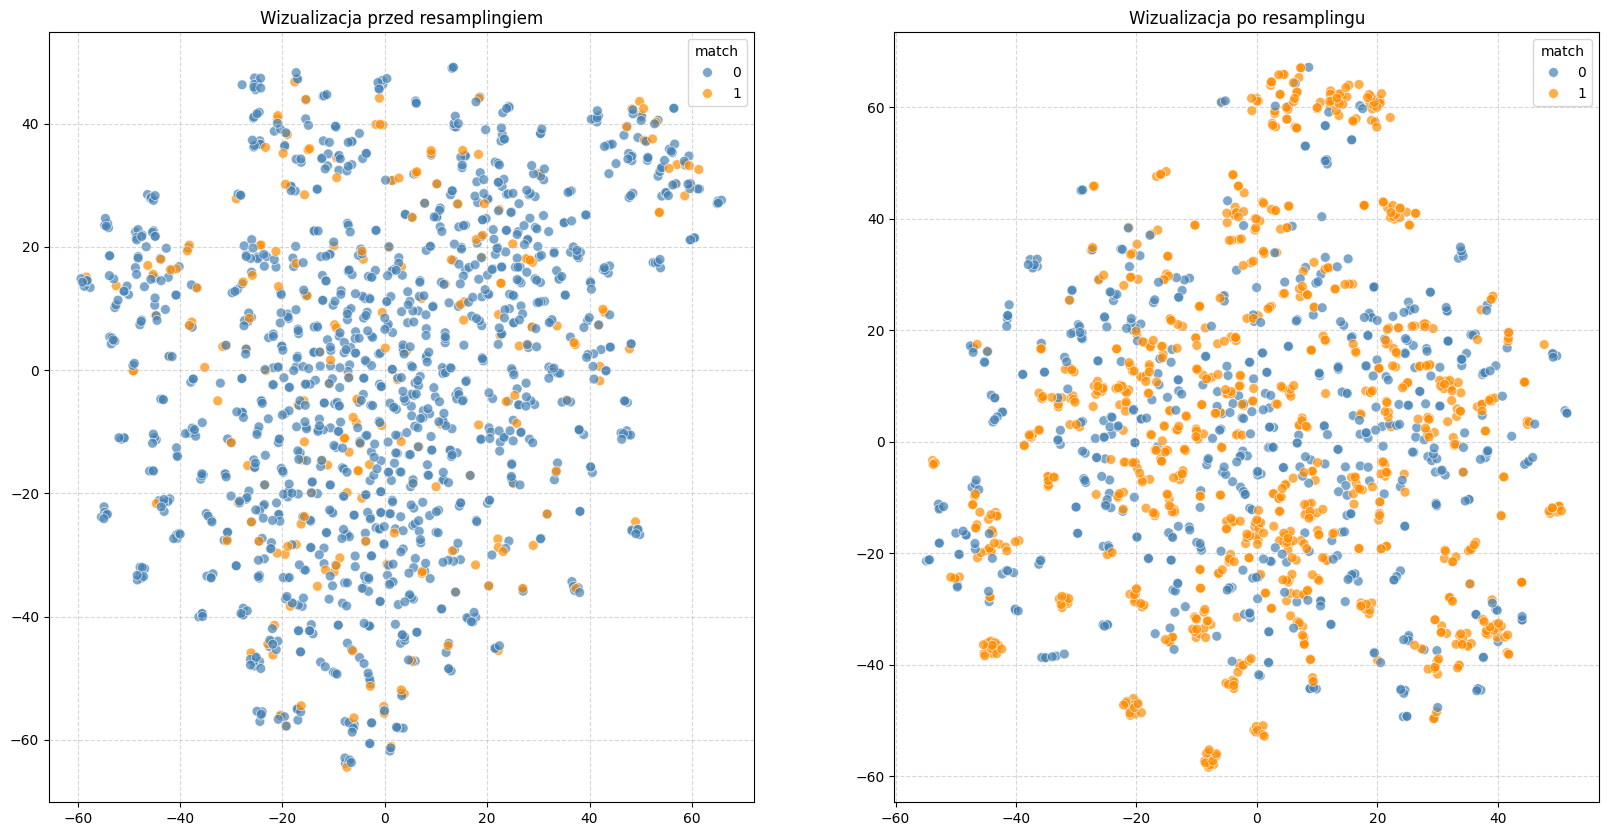

In [421]:
sample_indices_smoteenn = np.random.choice(len(X_train_smoteenn), size=1500, replace=False)

X_sample_smoteenn = X_train_smoteenn[sample_indices_smoteenn]
y_sample_smoteenn = y_train_smoteenn.iloc[sample_indices_smoteenn]

X_tsne_smoteenn = tsne.fit_transform(X_sample_smoteenn)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
axes = axes.flatten()

sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=y_sample, 
    palette={0: 'steelblue', 1: 'darkorange'},
    alpha=0.7,
    s=50,
    ax=axes[0]
)
axes[0].set_title('Wizualizacja przed resamplingiem')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    x=X_tsne_smoteenn[:, 0], 
    y=X_tsne_smoteenn[:, 1], 
    hue=y_sample_smoteenn, 
    palette={0: 'steelblue', 1: 'darkorange'},
    alpha=0.7,
    s=50,
    ax=axes[1]
)
axes[1].set_title('Wizualizacja po resamplingu')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

In [422]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smoteenn, y_train_smoteenn)
y_pred_lr = log_reg.predict(X_test_s)

print("Wyniki regresji logistycznej:")
print(classification_report_imbalanced(y_test, y_pred_lr))

d_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
d_tree.fit(X_train_smoteenn, y_train_smoteenn)
y_pred_dt = d_tree.predict(X_test_s)

print("Wyniki drzewa decyzyjnego:")
print(classification_report_imbalanced(y_test, y_pred_dt))

Wyniki regresji logistycznej:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.89      0.45      0.74      0.60      0.58      0.32      2172
          1       0.22      0.74      0.45      0.34      0.58      0.34       468

avg / total       0.77      0.50      0.69      0.55      0.58      0.33      2640

Wyniki drzewa decyzyjnego:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      0.56      0.59      0.68      0.58      0.33      2172
          1       0.23      0.59      0.56      0.33      0.58      0.33       468

avg / total       0.75      0.57      0.58      0.62      0.58      0.33      2640



## Ensemble
### 1. Random Forest

In [423]:
random_forest = RandomForestClassifier(class_weight='balanced', random_state=42)
random_forest.fit(X_train_s, y_train)
y_pred_rf = random_forest.predict(X_test_s)

print("Wyniki lasu losowego:")
print(classification_report_imbalanced(y_test, y_pred_rf))

Wyniki lasu losowego:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.85      0.93      0.21      0.89      0.44      0.21      2172
          1       0.41      0.21      0.93      0.28      0.44      0.18       468

avg / total       0.77      0.81      0.34      0.78      0.44      0.20      2640



### 2. Balanced Random Forest

In [424]:
brf = BalancedRandomForestClassifier(random_state=42)
brf.fit(X_train_s, y_train)
y_pred_brf = brf.predict(X_test_s)

print("Wyniki Balanced Random Forest:")
print(classification_report_imbalanced(y_test, y_pred_brf))

Wyniki Balanced Random Forest:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      0.82      0.37      0.84      0.55      0.32      2172
          1       0.31      0.37      0.82      0.34      0.55      0.29       468

avg / total       0.76      0.74      0.45      0.75      0.55      0.31      2640



### 3. Easy Ensemble Classifier

In [425]:
eec = EasyEnsembleClassifier(random_state=42)
eec.fit(X_train_s, y_train)
y_pred_eec = eec.predict(X_test_s)

print("Wyniki Easy Ensemble Classifier")
print(classification_report_imbalanced(y_test, y_pred_eec))

Wyniki Easy Ensemble Classifier
                   pre       rec       spe        f1       geo       iba       sup

          0       0.87      0.61      0.59      0.72      0.60      0.36      2172
          1       0.25      0.59      0.61      0.35      0.60      0.36       468

avg / total       0.76      0.61      0.60      0.66      0.60      0.36      2640



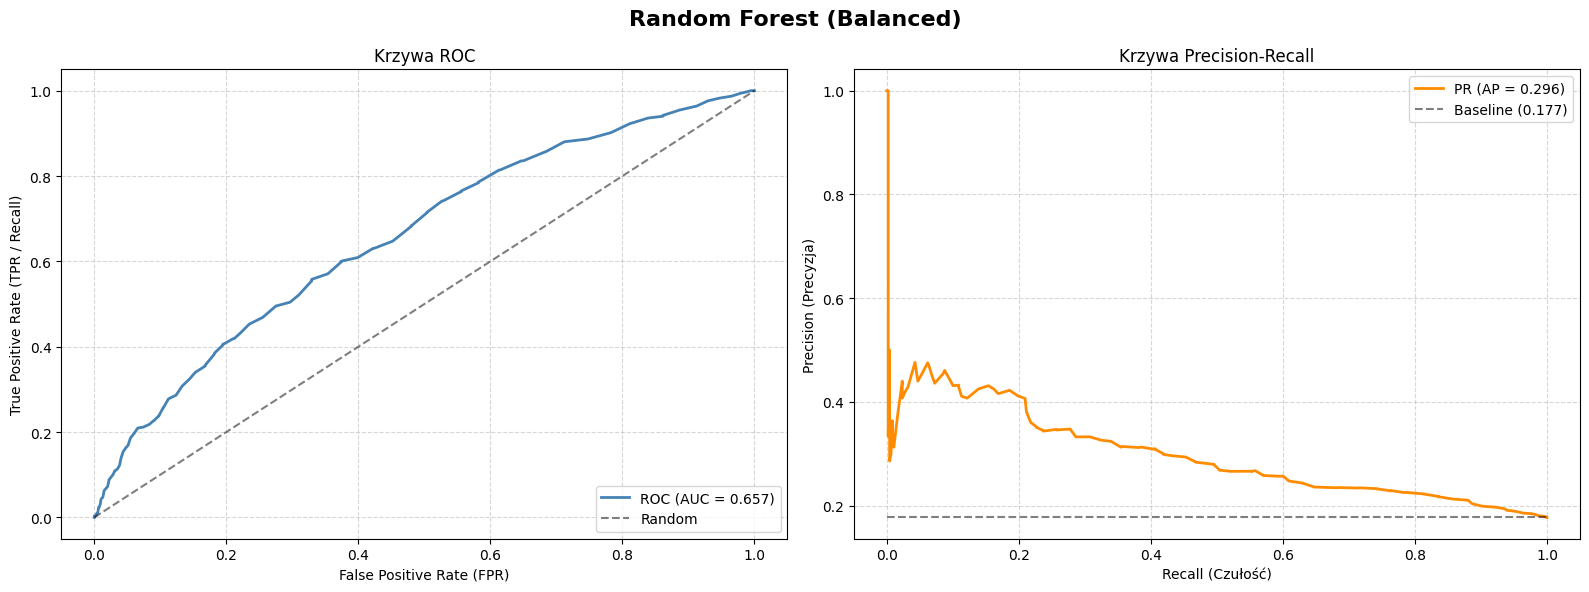

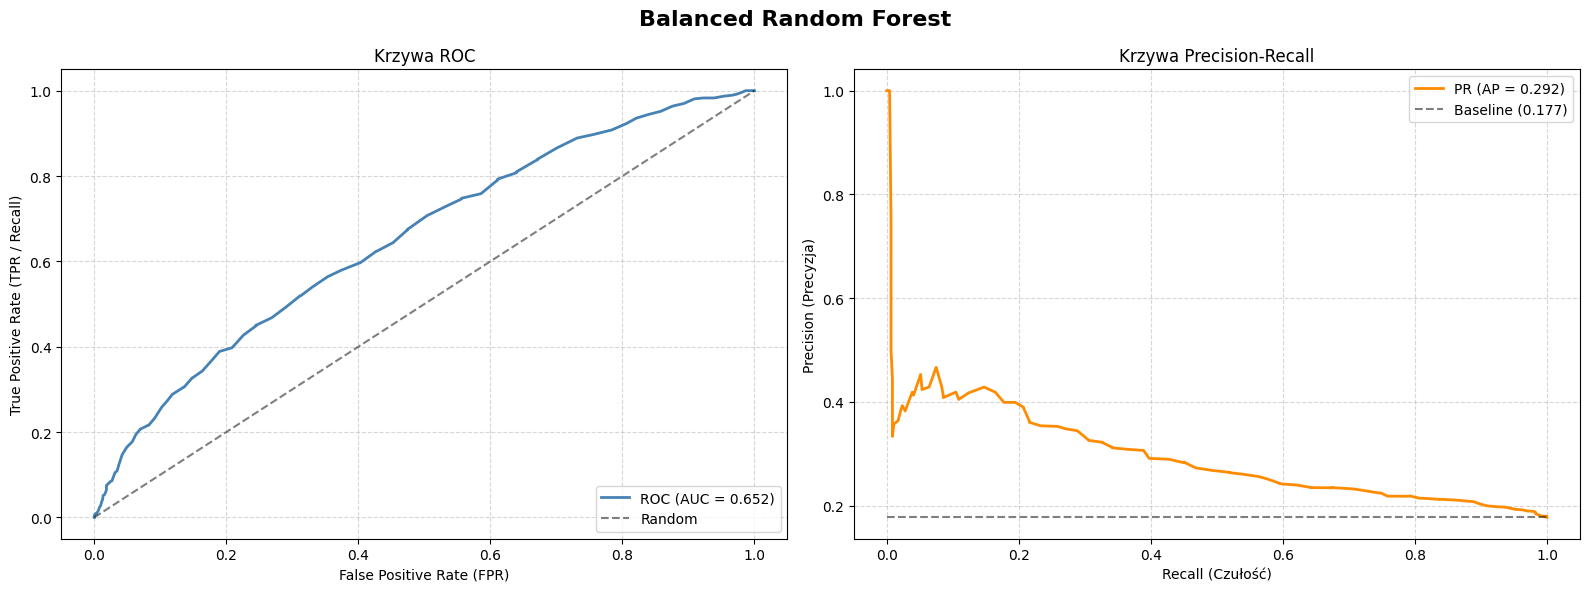

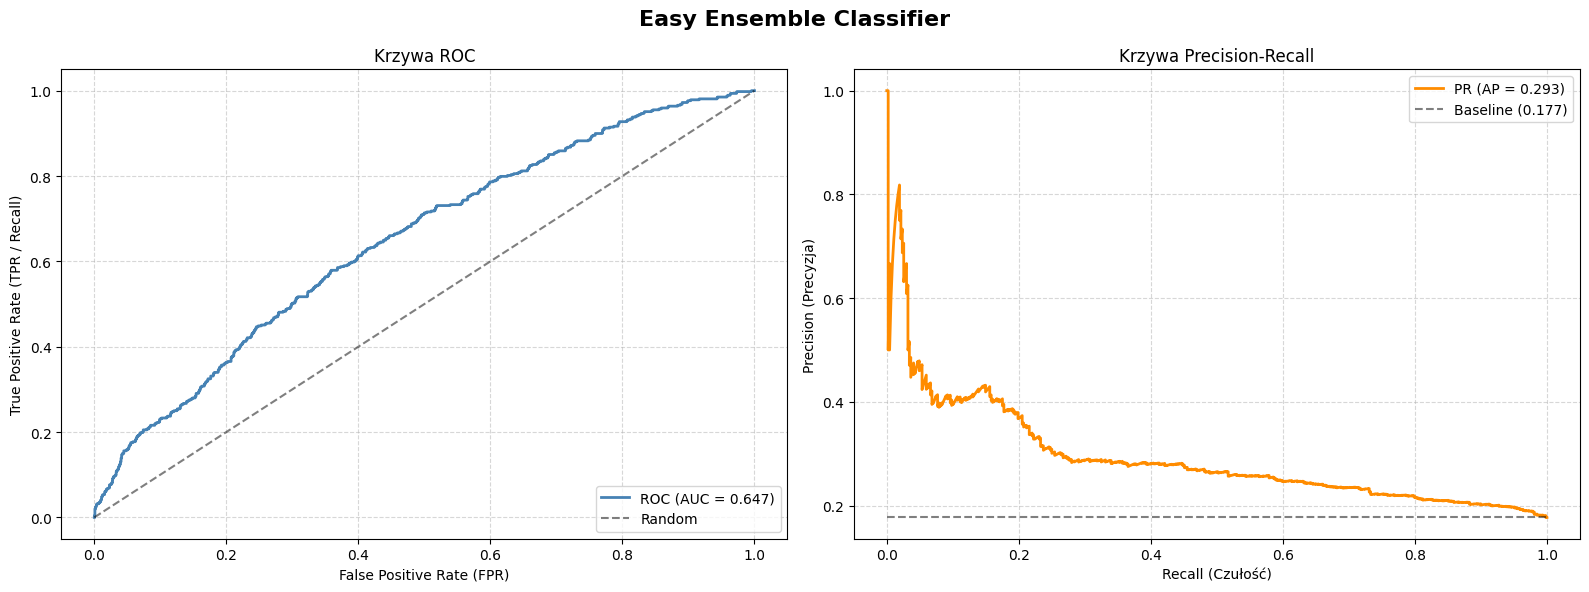

In [426]:
y_prob_rf = random_forest.predict_proba(X_test_s)[:, 1]
y_prob_brf = brf.predict_proba(X_test_s)[:, 1]
y_prob_eec = eec.predict_proba(X_test_s)[:, 1]

models_probs = {
    'Random Forest (Balanced)': y_prob_rf,
    'Balanced Random Forest': y_prob_brf,
    'Easy Ensemble Classifier': y_prob_eec
}

baseline = y_test.mean()

for name, prob in models_probs.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    fig.suptitle(name, fontsize=16, fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    
    axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    
    axes[0].set_title('Krzywa ROC')
    axes[0].set_xlabel('False Positive Rate (FPR)')
    axes[0].set_ylabel('True Positive Rate (TPR / Recall)')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    
    axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'PR (AP = {ap:.3f})')
    axes[1].plot([0, 1], [baseline, baseline], 'k--', alpha=0.5, label=f'Baseline ({baseline:.3f})')
    
    axes[1].set_title('Krzywa Precision-Recall')
    axes[1].set_xlabel('Recall (Czułość)')
    axes[1].set_ylabel('Precision (Precyzja)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()